# Experimental Design and Factorial Design Experiment

In [12]:
import pymc3 as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set_theme(style="whitegrid")


In [13]:
factor_A = [0, 0, 1, 1]
factor_B = [0, 1, 0, 1]

N = np.array([250, 250, 250, 250])
purchase = np.array([20, 28, 12, 40])

data = np.vstack([purchase, N - purchase, factor_A, factor_B]).T

df = pd.DataFrame(data)
df.columns = ['purchase', 'no_purchase', 'factor_A', 'factor_B']

In [14]:
df

,purchase,no_purchase,factor_A,factor_B
0,20,230,0,0
1,28,222,0,1
2,12,238,1,0
3,40,210,1,1


# EDA

In [59]:
# factor_A = ["grid", "grid", "list", "list"]
# factor_B = ["white", "green", "white", "green"]
#
# N = np.array([250, 250, 250, 250])
# purchase = np.array([20, 28, 12, 40])
#
# data = np.vstack([purchase, N - purchase, factor_A, factor_B]).T
#
# df = pd.DataFrame(data)
# df.columns = ['purchase', 'no_purchase', 'layout', 'background']
# df['purchase'] = df['purchase'].astype('int')
# df

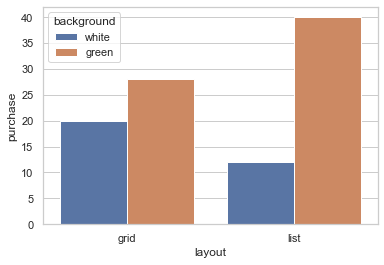

In [62]:
# https://seaborn.pydata.org/examples/grouped_barplot.html
# https://seaborn.pydata.org/generated/seaborn.barplot.html

ax = sns.barplot(data=df, x="layout", hue="background", y="purchase")

#g.legend.set_title("")
plt.show()

#plt.bar(['(A, B) = (0, 0)', '(A, B) = (0, 1)', '(A, B) = (1, 0)', '(A, B) = (1, 1)'], purchase)
#plt.ylabel('# purchases')
#plt.show()

# A Simple Approach

The simplest approach for analyzing whether there is a difference between designs' conversion rates is to treat the experiment as 1-factor 4-level study. Using the same approach that we used to compare two designs's conversion rates, we compare the posterior distributions of four designs.

In [15]:
len(N)

4

In [16]:
with pm.Model() as model:
    theta = pm.Uniform('theta', lower=0, upper=1, shape=len(N))
    obs = pm.Binomial('obs', p=theta, n=N, observed=purchase)
    trace = pm.sample(5000, chains=2)


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_35161/4010127323.py:4: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(5000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [theta]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 5 seconds.


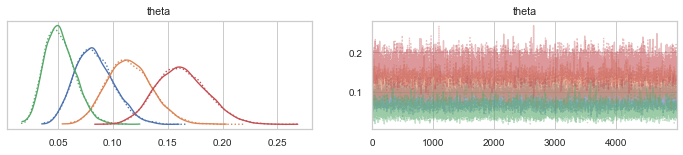

In [17]:
with model:
    az.plot_trace(trace, compact=True)

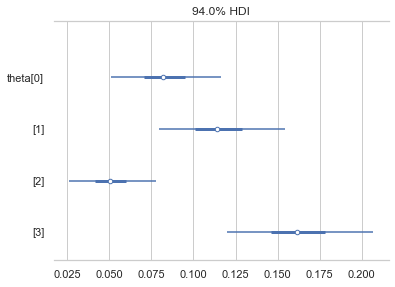

In [5]:
with model:
    az.plot_forest(trace, combined=True)

# Analyzing the Data with Bayesian Generalized Linear Model

In [18]:
import pymc3 as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

layout = [0, 0, 1, 1]
background = [0, 1, 0, 1]

N = np.array([250, 250, 250, 250])
purchase = np.array([20, 28, 12, 40])

with pm.Model() as model_logistic:
    b0 = pm.Normal('b0', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=10, shape=2)

    comb = b0 + beta[0] * layout + beta[1] * background
    theta = pm.Deterministic('theta', pm.math.invlogit(comb))
    #theta = pm.math.invlogit(comb)

    obs = pm.Binomial('obs', p=theta, n=N, observed=purchase)
    trace_logistic = pm.sample(5000, chains=2)


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_35161/1475565657.py:21: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace_logistic = pm.sample(5000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [beta, b0]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 6 seconds.
The acceptance probability does not match the target. It is 0.8873757716197959, but should be close to 0.8. Try to increase the number of tuning steps.
The acceptance probability does not match the target. It is 0.888203453601384, but should be close to 0.8. Try to increase the number of tuning steps.


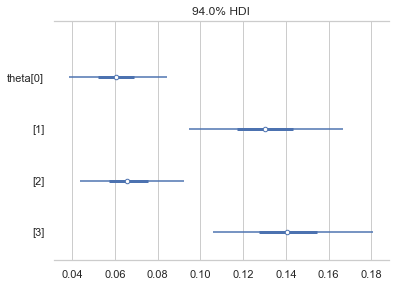

In [19]:
with model_logistic:
    az.plot_forest(
        trace_logistic,
        var_names=['theta'],
        combined=True
    )

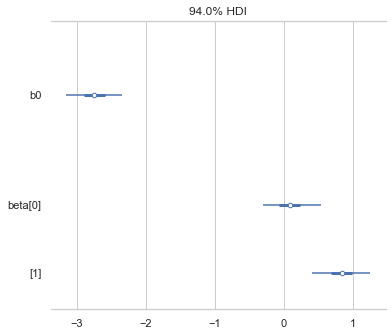

In [8]:
with model_logistic:
    az.plot_forest(
        trace_logistic,
        var_names=['b0', 'beta'],
        combined=True
    )

# Factorial model with a logistic regression (with interaction)

In [9]:
import pymc3 as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

layout = [0, 0, 1, 1]
background = [0, 1, 0, 1]

N = np.array([250, 250, 250, 250])
purchase = np.array([20, 28, 12, 40])

with pm.Model() as model_logistic_interaction:
    b0 = pm.Normal('b0', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=10, shape=2)
    b12 = pm.Normal('b12', mu=0, sigma=10)
    comb = b0 + beta[0] * layout + beta[1] * background + b12 * layout * background

    # theta = pm.Deterministic('theta', 1 / (1 + pm.math.exp(-comb)))
    theta = pm.Deterministic('theta', pm.math.invlogit(comb))
    obs = pm.Binomial('obs', p=theta, n=N, observed=purchase)
    trace_logistic_interaction = pm.sample(5000, chains=2)


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_35161/2969559075.py:21: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace_logistic_interaction = pm.sample(5000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [b12, beta, b0]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 8 seconds.
The acceptance probability does not match the target. It is 0.8844351404608886, but should be close to 0.8. Try to increase the number of tuning steps.
The acceptance probability does not match the target. It is 0.8883160986547364, but should be close to 0.8. Try to increase the number of tuning steps.


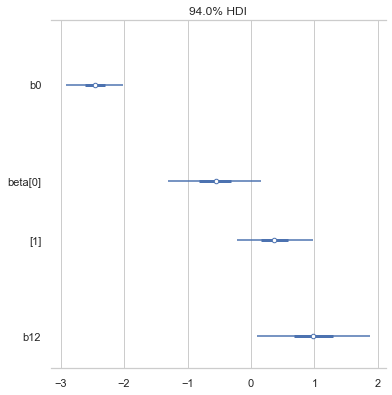

In [10]:
with model_logistic_interaction:
    az.plot_forest(
        trace_logistic_interaction,
        var_names=['b0', 'beta', 'b12'],
        combined=True)

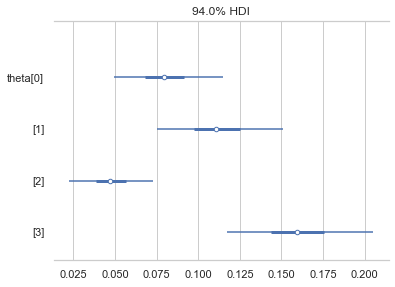

In [11]:
with model_logistic_interaction:
    az.plot_forest(trace_logistic_interaction, var_names=['theta'], combined=True)